In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional aesthetic for your plots
sns.set_theme(style="whitegrid", palette="muted")

# 1. Load Data
df = pd.read_csv('../data/application_train.csv')

print(f"Dataset Shape: {df.shape}")

Dataset Shape: (307511, 122)


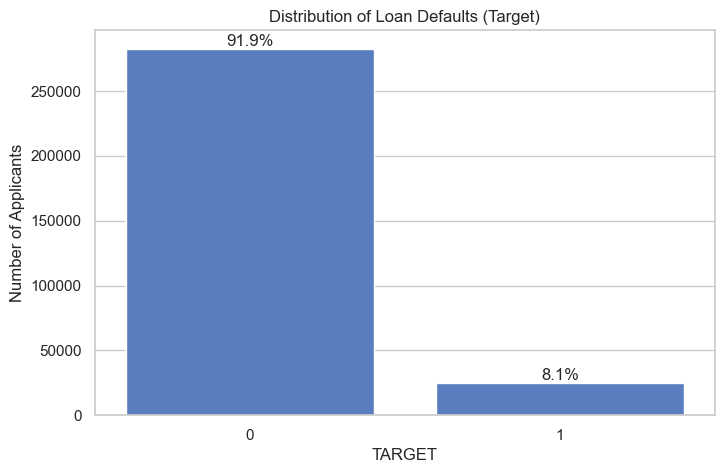

In [4]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='TARGET')
plt.title('Distribution of Loan Defaults (Target)')
plt.ylabel('Number of Applicants')

# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')
plt.show()

Plot showing an imbalanced classification problem in dataset, problem will be look into later.

"We will try several approaches to this problem: single model undersampling, single model imbalanced downsampling, ensemble modelling using imbalanced downsampling, and gradient boosting via XGBoost. We will avoid synthestic oversampling because SMOTE techniques do not perform very well with large numbers of features as we have here."

In [ ]:
# --- Evaluate Missing Data ---
# Calculate percentage of missing values per column
missing_data = df.isnull().sum() / len(df) * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

print("Top 0 Features with Missing Data (%):")
print(missing_data.head(20))

Top 10 Features with Missing Data (%):
COMMONAREA_MEDI             69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_AVG              69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MEDI              67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_AVG                59.376738
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
dtype: float64


These column suffers from data sparsity, with missing rates ranging from 59% to 70%. 

This suggests that these specific data points are either not mandatory during the loan application process or are not applicable to the majority of the applicant pool.

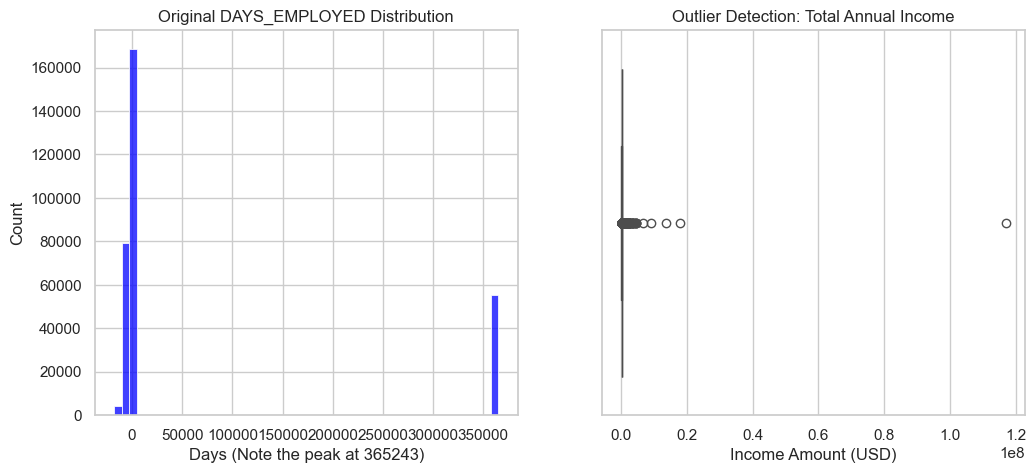

--- Severe Anomaly Statistics ---
99th Percentile Income: $472,500.00
Applicants above this threshold: 3014
Max Income found: $117,000,000.00


In [16]:
# --- Evaluate Anomaly Data ---
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Visualize the Logical Anomaly: DAYS_EMPLOYED
# We already identified 365243 as the anomalous value.
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['DAYS_EMPLOYED'], bins=50, kde=False, color='blue')
plt.title('Original DAYS_EMPLOYED Distribution')
plt.xlabel('Days (Note the peak at 365243)')

# 2. Visualize Statistical Outliers: AMT_INCOME_TOTAL
plt.subplot(1, 2, 2)
# Using a boxplot to identify severe outliers in Income
sns.boxplot(x=df['AMT_INCOME_TOTAL'], color='orange')
plt.title('Outlier Detection: Total Annual Income')
plt.xlabel('Income Amount (USD)')
plt.show()

# Print statistics for "Severe" Anomalies
income_threshold = df['AMT_INCOME_TOTAL'].quantile(0.99) # Top 1%
severe_income = df[df['AMT_INCOME_TOTAL'] > income_threshold]

print(f"--- Severe Anomaly Statistics ---")
print(f"99th Percentile Income: ${income_threshold:,.2f}")
print(f"Applicants above this threshold: {len(severe_income)}")
print(f"Max Income found: ${df['AMT_INCOME_TOTAL'].max():,.2f}")


In [ ]:
# The value 365243 is a known anomaly in DAYS_EMPLOYED representing 'Unemployed'
anom = df[df['DAYS_EMPLOYED'] == 365243]
non_anom = df[df['DAYS_EMPLOYED'] != 365243]

print(f"Default rate for anomalies: {100 * anom['TARGET'].mean():.2f}%")
print(f"Default rate for non-anomalies: {100 * non_anom['TARGET'].mean():.2f}%")
print(f"Number of anomalies: {len(anom)}")

Default rate for anomalies: 5.40%
Default rate for non-anomalies: 8.66%
Number of anomalies: 55374


The dataset contains two primary types of severe anomalies that could mislead a machine learning model if left untreated:

Logical Constant (365243 in DAYS_EMPLOYED): This value represents approximately 1,000 years of employment, which is physically impossible. Since this group has a significantly different default rate (5.4% vs 8.7%), this "anomaly" actually contains a hidden signal—likely representing retirees or the long-term unemployed.

Financial Extreme Outliers (AMT_INCOME_TOTAL): While having a high income is possible, extreme outliers (e.g., the maximum value being hundreds of times higher than the median) create a "skew" that can prevent Gradient Boosting models like LightGBM from learning the patterns of "normal" applicants.


--
For Logical Anomalies: We will create an auxiliary binary "flag" feature (e.g., DAYS_EMPLOYED_ANOM) to preserve the signal before replacing the anomalous value with NaN or a median for imprinting.

For Statistical Outliers: We will implement Cap and Floor (Winsorization) or use a Log Transformation on financial features to compress these extreme ranges into a more "digestible" scale for the model. This ensures that one "billionaire" applicant does not disproportionately shift the model's decision boundaries for the rest of the 99% of users.

C:\Users\User\AppData\Local\Temp\ipykernel_18428\3128548871.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_18428\3128548871.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='TARGET', data=cat_perc, palette='Reds_r')


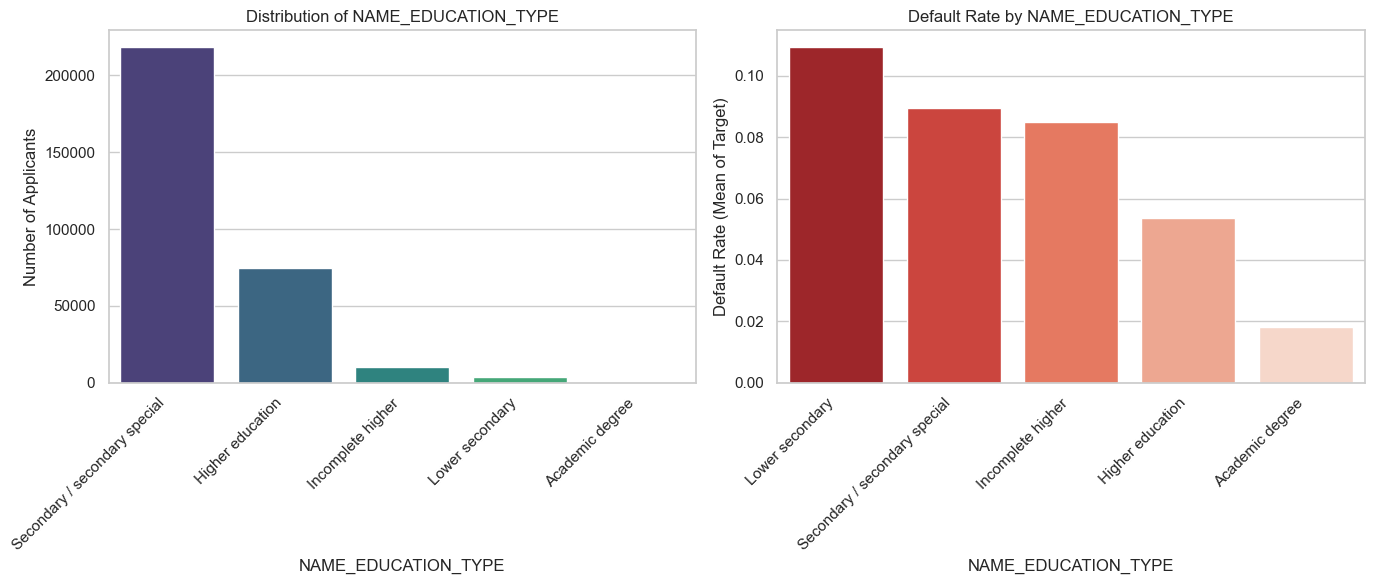

C:\Users\User\AppData\Local\Temp\ipykernel_18428\3128548871.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_18428\3128548871.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='TARGET', data=cat_perc, palette='Reds_r')


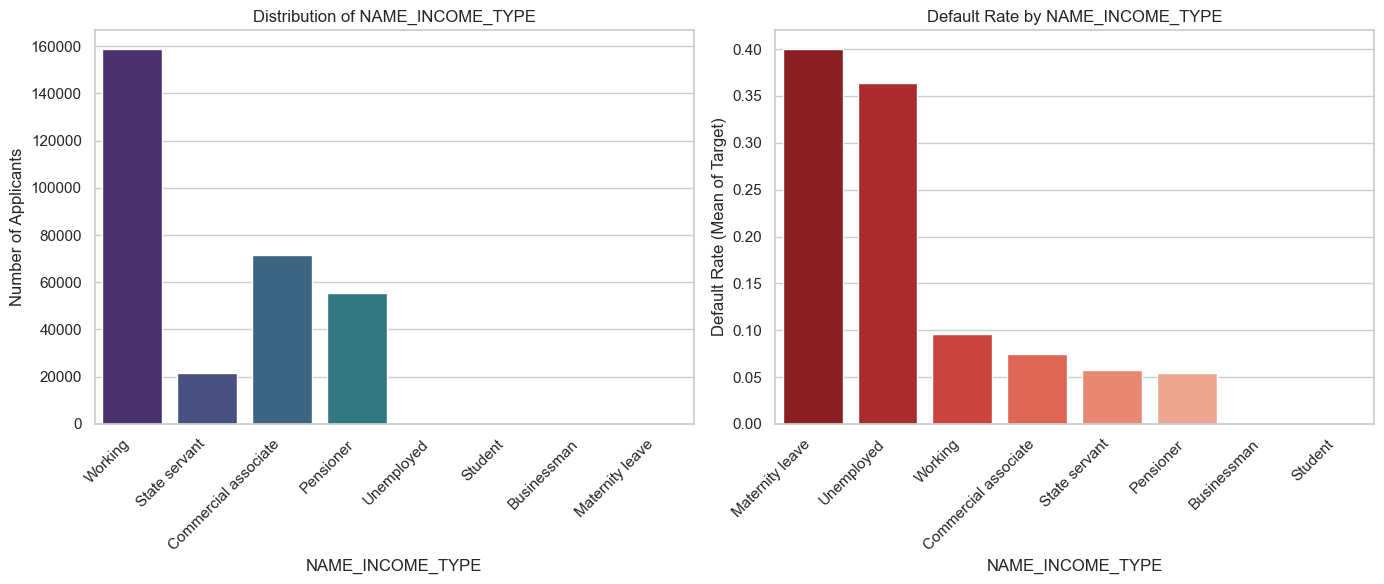

In [12]:
# --- Categorical Analysis ---

def plot_categorical_stats(feature, df):
    """Plot distribution and default rate for categorical features."""
    plt.figure(figsize=(14, 6))
    
    # 1. Distribution of the feature
    plt.subplot(1, 2, 1)
    sns.countplot(data=df, x=feature, palette='viridis')
    plt.title(f'Distribution of {feature}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Number of Applicants')
    
    # 2. Default Rate per category
    plt.subplot(1, 2, 2)
    # Calculate mean of TARGET (which is the default rate)
    cat_perc = df[[feature, 'TARGET']].groupby([feature], as_index=False).mean().sort_values(by='TARGET', ascending=False)
    sns.barplot(x=feature, y='TARGET', data=cat_perc, palette='Reds_r')
    plt.title(f'Default Rate by {feature}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Default Rate (Mean of Target)')
    
    plt.tight_layout()
    plt.show()

# Example: Analyze Education and Income Type
plot_categorical_stats('NAME_EDUCATION_TYPE', df)
plot_categorical_stats('NAME_INCOME_TYPE', df)

C:\Users\User\AppData\Local\Temp\ipykernel_18428\1890658218.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_eng["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace=True)


Newly Engineered Features:
   ANNUITY_INCOME_PERCENT  CREDIT_INCOME_PERCENT  EXT_SOURCES_MEAN
0                0.121978               2.007889          0.161787
1                0.132217               4.790750          0.466757
2                0.100000               2.000000          0.642739
3                0.219900               2.316167          0.650442
4                0.179963               4.222222          0.322738


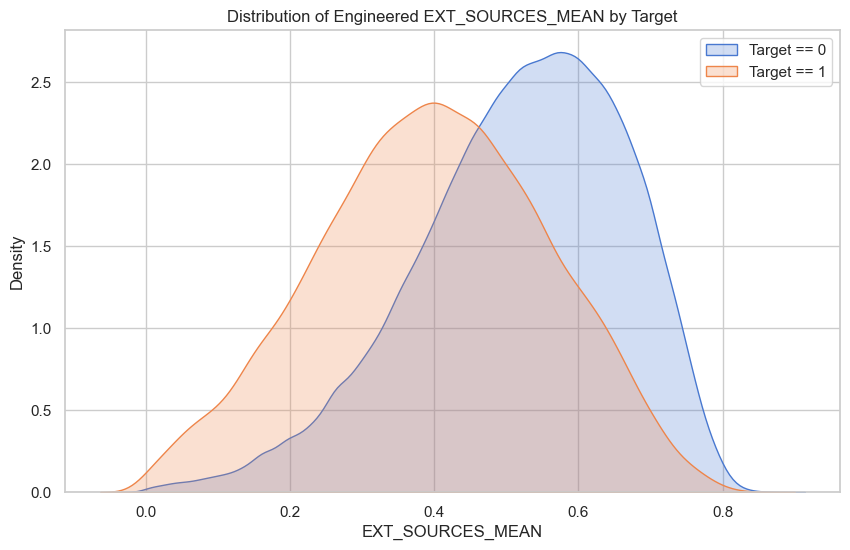

In [20]:
# --- Feature Engineering ---

# 1. Create a copy to prevent fragmentation warnings
df_eng = df.copy()

# 2. Handle the Employment Anomaly (as discussed)
df_eng['DAYS_EMPLOYED_ANOM'] = df_eng["DAYS_EMPLOYED"] == 365243
df_eng["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace=True)

# 3. Financial Ratios (The most usable and predictive features)
# % of income required to pay the monthly annuity
df_eng['ANNUITY_INCOME_PERCENT'] = df_eng['AMT_ANNUITY'] / df_eng['AMT_INCOME_TOTAL']

# Ratio of the credit amount to the applicant's total income
df_eng['CREDIT_INCOME_PERCENT'] = df_eng['AMT_CREDIT'] / df_eng['AMT_INCOME_TOTAL']

# "Credit Term" - how many months/years the credit is for
df_eng['CREDIT_TERM'] = df_eng['AMT_ANNUITY'] / df_eng['AMT_CREDIT']

# Percentage of life spent employed
df_eng['DAYS_EMPLOYED_PERCENT'] = df_eng['DAYS_EMPLOYED'] / df_eng['DAYS_BIRTH']

# 4. External Source Aggregation
# Average of the three external sources (handling NaNs automatically)
df_eng['EXT_SOURCES_MEAN'] = df_eng[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)

print("Newly Engineered Features:")
print(df_eng[['ANNUITY_INCOME_PERCENT', 'CREDIT_INCOME_PERCENT', 'EXT_SOURCES_MEAN']].head())

# 5. Visualizing a new feature's predictive power
plt.figure(figsize=(10, 6))
sns.kdeplot(df_eng.loc[df_eng['TARGET'] == 0, 'EXT_SOURCES_MEAN'], label='Target == 0', fill=True)
sns.kdeplot(df_eng.loc[df_eng['TARGET'] == 1, 'EXT_SOURCES_MEAN'], label='Target == 1', fill=True)
plt.title('Distribution of Engineered EXT_SOURCES_MEAN by Target')
plt.legend()
plt.show()

In [18]:
# Create a function to quickly compare continuous variables
def plot_target_kde(feature_name, data):
    plt.figure(figsize=(10, 5))
    
    # Plot distribution for Target == 0 (Repaid)
    sns.kdeplot(data=data[data['TARGET'] == 0][feature_name], 
                label='Target == 0 (Repaid)', 
                fill=True, color='green', alpha=0.3)
    
    # Plot distribution for Target == 1 (Default)
    sns.kdeplot(data=data[data['TARGET'] == 1][feature_name], 
                label='Target == 1 (Default)', 
                fill=True, color='red', alpha=0.3)
    
    plt.title(f'Distribution of {feature_name} by Target')
    plt.xlabel(feature_name)
    plt.ylabel('Density')
    plt.legend()
    plt.show()

# Example Usage: Compare Age (converting negative days to positive years)
# df['AGE_YEARS'] = abs(df['DAYS_BIRTH']) / 365
# plot_target_kde('AGE_YEARS', df)

# Example Usage 2: Compare External Source 2
# plot_target_kde('EXT_SOURCE_2', df)

Most Positive Correlations (Associated with Default):
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64

Most Negative Correlations (Associated with Repayment):
EXT_SOURCES_MEAN     -0.222052
EXT_SOURCE_3         -0.178919
EXT_SOURCE_2         -0.160472
EXT_SOURCE_1         -0.155317
AGE_YEARS            -0.078239
DAYS_EMPLOYED_ANOM   -0.045987
DAYS_EMPLOYED        -0.044932
FLOORSMAX_AVG        -0.044003
FLOORSMAX_MEDI       -0.043768
FLOORSMAX_MODE       -0.043226
Name: TARGET, dtype: float64


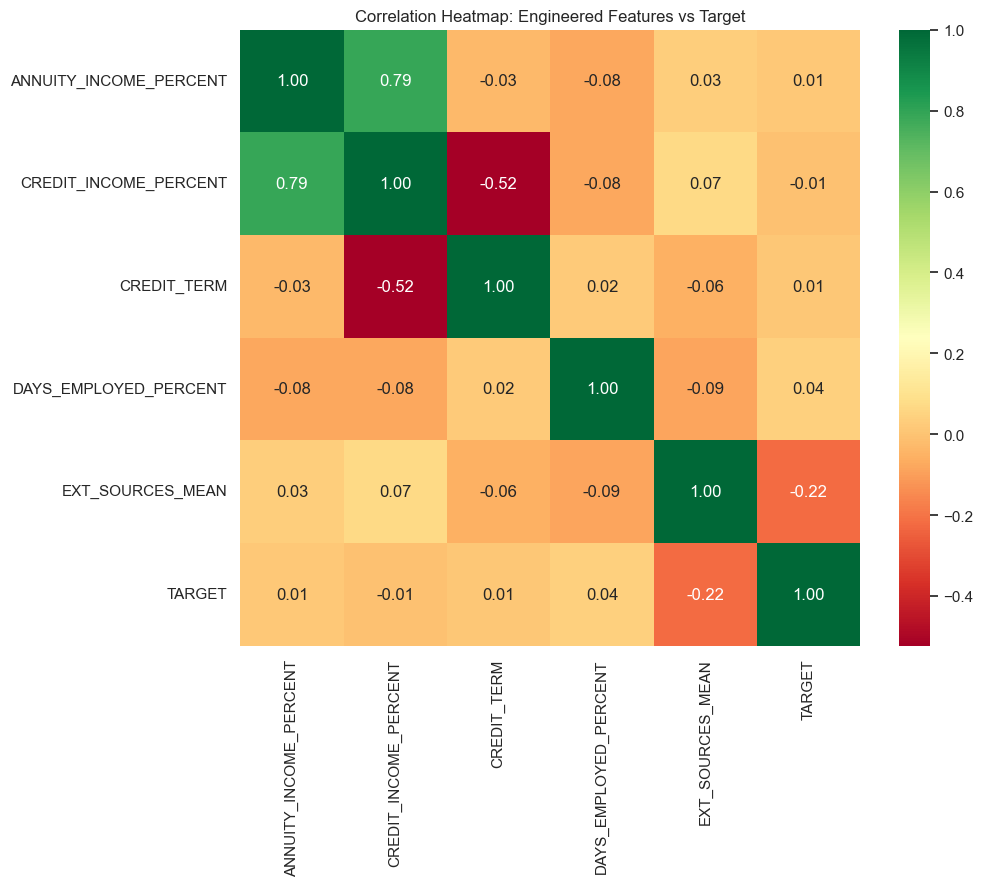

In [22]:
# --- Feature Selection: Correlation Analysis ---

# 1. Calculate correlations between all features and the target
correlations = df_eng.corr(numeric_only=True)['TARGET'].sort_values()

print('Most Positive Correlations (Associated with Default):')
print(correlations.tail(10))

print('\nMost Negative Correlations (Associated with Repayment):')
print(correlations.head(10))

# 2. Visualize top correlations for your new engineered features
engineered_cols = ['ANNUITY_INCOME_PERCENT', 'CREDIT_INCOME_PERCENT', 
                   'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT', 'EXT_SOURCES_MEAN', 'TARGET']

plt.figure(figsize=(10, 8))
sns.heatmap(df_eng[engineered_cols].corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap: Engineered Features vs Target')
plt.show()

Top 20 Strongest Original Features (by Absolute Correlation):
EXT_SOURCE_3                   0.178919
EXT_SOURCE_2                   0.160472
EXT_SOURCE_1                   0.155317
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_EMPLOYED_ANOM             0.045987
FLAG_EMP_PHONE                 0.045982
DAYS_EMPLOYED                  0.044932
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
FLOORSMAX_AVG                  0.044003
FLOORSMAX_MEDI                 0.043768
FLOORSMAX_MODE                 0.043226
DAYS_REGISTRATION              0.041975
AMT_GOODS_PRICE                0.039645
OWN_CAR_AGE                    0.037612
Name: TARGET, dtype: float64


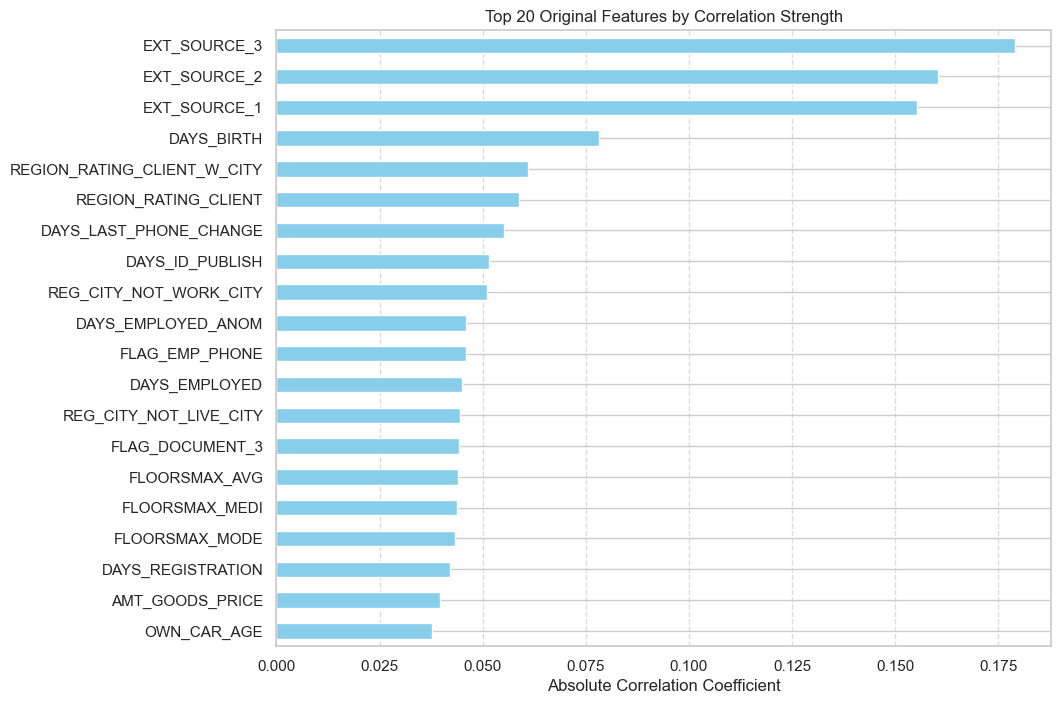

In [24]:
# --- Identify Top 20 Strongest Original Features ---

# 1. Calculate absolute correlation to find "strength" regardless of direction
# We exclude the engineered features to focus on raw inputs
engineered_list = ['ANNUITY_INCOME_PERCENT', 'CREDIT_INCOME_PERCENT', 
                   'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT', 'EXT_SOURCES_MEAN', 'AGE_YEARS']

# 2. Get all numeric correlations
all_corrs = df_eng.corr(numeric_only=True)['TARGET'].abs()

# 3. Drop the engineered ones and the TARGET itself from the list
original_corrs = all_corrs.drop(labels=engineered_list + ['TARGET'], errors='ignore')

# 4. Get the Top 20
top_20_features = original_corrs.sort_values(ascending=False).head(20)

print("Top 20 Strongest Original Features (by Absolute Correlation):")
print(top_20_features)

# 5. Visualize the strength
plt.figure(figsize=(10, 8))
top_20_features.sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 20 Original Features by Correlation Strength')
plt.xlabel('Absolute Correlation Coefficient')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [28]:
import pandas as pd
import numpy as np

# Assuming 'df' is your original loaded dataset
excluded_normalized_features = []

# Iterate through all columns
for col in df.columns:
    # Skip the ID and TARGET columns so we don't accidentally process them
    if col in ['SK_ID_CURR', 'TARGET']:
        continue
        
    # Check if the column type is a float (algorithms generate floats, user inputs are usually ints or text)
    if pd.api.types.is_float_dtype(df[col]):
        # Get min and max, automatically ignoring NaNs
        min_val = df[col].min()
        max_val = df[col].max()
        
        # Rule: Exclude if the float values strictly fall between 0.0 and 1.0
        if min_val >= 0.0 and max_val <= 1.0:
            excluded_normalized_features.append(col)

# Save the remaining raw features in a new variable (excluding ID and TARGET)
remaining_features_pool = [col for col in df.columns 
                           if col not in excluded_normalized_features 
                           and col not in ['SK_ID_CURR', 'TARGET']]

# Print the results matching your format
print("Features excluded in this round [Calculated floats 0-1]:\n")
print(f"[{', '.join(excluded_normalized_features)}]")

print(f"\nTotal excluded features: {len(excluded_normalized_features)}")
print(f"Total remaining usable features: {len(remaining_features_pool)}")
print(f"[{', '.join(remaining_features_pool)}]")


Features excluded in this round [Calculated floats 0-1]:

[REGION_POPULATION_RELATIVE, EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3, APARTMENTS_AVG, BASEMENTAREA_AVG, YEARS_BEGINEXPLUATATION_AVG, YEARS_BUILD_AVG, COMMONAREA_AVG, ELEVATORS_AVG, ENTRANCES_AVG, FLOORSMAX_AVG, FLOORSMIN_AVG, LANDAREA_AVG, LIVINGAPARTMENTS_AVG, LIVINGAREA_AVG, NONLIVINGAPARTMENTS_AVG, NONLIVINGAREA_AVG, APARTMENTS_MODE, BASEMENTAREA_MODE, YEARS_BEGINEXPLUATATION_MODE, YEARS_BUILD_MODE, COMMONAREA_MODE, ELEVATORS_MODE, ENTRANCES_MODE, FLOORSMAX_MODE, FLOORSMIN_MODE, LANDAREA_MODE, LIVINGAPARTMENTS_MODE, LIVINGAREA_MODE, NONLIVINGAPARTMENTS_MODE, NONLIVINGAREA_MODE, APARTMENTS_MEDI, BASEMENTAREA_MEDI, YEARS_BEGINEXPLUATATION_MEDI, YEARS_BUILD_MEDI, COMMONAREA_MEDI, ELEVATORS_MEDI, ENTRANCES_MEDI, FLOORSMAX_MEDI, FLOORSMIN_MEDI, LANDAREA_MEDI, LIVINGAPARTMENTS_MEDI, LIVINGAREA_MEDI, NONLIVINGAPARTMENTS_MEDI, NONLIVINGAREA_MEDI, TOTALAREA_MODE]

Total excluded features: 47
Total remaining usable features: 74
[NAME_